In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

In [11]:
train_path = "project/data/train_FD001.txt"

train = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)
train.columns = columns
train.head()

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [12]:
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

drop_sensors = ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']

selected_sensors = [s for s in sensor_cols if s not in drop_sensors]

print(selected_sensors)
print("Number of selected sensors:", len(selected_sensors))

['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']
Number of selected sensors: 14


In [13]:
data = train[['engine_id', 'cycle'] + selected_sensors].copy()
data.head()

,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [14]:
scaler = MinMaxScaler()
data[selected_sensors] = scaler.fit_transform(data[selected_sensors])

data.head()

,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [15]:
healthy_parts = []

for engine_id in data['engine_id'].unique():
    engine_df = data[data['engine_id'] == engine_id].copy()
    max_cycle = engine_df['cycle'].max()
    healthy_df = engine_df[engine_df['cycle'] <= 0.5 * max_cycle]
    healthy_parts.append(healthy_df)

healthy_data = pd.concat(healthy_parts, ignore_index=True)

print("Original shape:", data.shape)
print("Healthy shape:", healthy_data.shape)

Original shape: (20631, 16)
Healthy shape: (10290, 16)


In [16]:
engines = healthy_data['engine_id'].unique()

np.random.seed(42)
np.random.shuffle(engines)

split_idx = int(len(engines) * 0.8)

train_engines = engines[:split_idx]
val_engines = engines[split_idx:]

train_df = healthy_data[healthy_data['engine_id'].isin(train_engines)].copy()
val_df = healthy_data[healthy_data['engine_id'].isin(val_engines)].copy()

print("Train engines:", len(train_engines))
print("Val engines:", len(val_engines))
print("Train df shape:", train_df.shape)
print("Val df shape:", val_df.shape)

Train engines: 80
Val engines: 20
Train df shape: (8152, 16)
Val df shape: (2138, 16)


In [17]:
def create_windows(df, sensor_cols, window_size):
    windows = []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        sensor_array = engine_df[sensor_cols].values

        for i in range(len(sensor_array) - window_size + 1):
            window = sensor_array[i:i + window_size]
            windows.append(window)

    return np.array(windows)

In [18]:
window_size = 30

X_train = create_windows(train_df, selected_sensors, window_size)
X_val = create_windows(val_df, selected_sensors, window_size)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (5832, 30, 14)
X_val shape: (1558, 30, 14)


In [19]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)

X_train_flat: (5832, 420)
X_val_flat: (1558, 420)


In [21]:
feature_mean = X_train_flat.mean(axis=0)
feature_std = X_train_flat.std(axis=0)
feature_std = feature_std + 1e-8

In [22]:
z_scores = np.abs((X_val_flat - feature_mean) / feature_std)

print(z_scores.shape)

(1558, 420)


In [23]:
anomaly_score = z_scores.max(axis=1)

print(anomaly_score[:10])

[3.17256619 3.16872739 3.16046874 3.15003697 3.14745394 3.14302437
 3.14537353 3.14857929 3.13907288 3.13660145]


In [24]:
threshold = 3.0
anomaly_flags = anomaly_score > threshold

print("Number of anomalous windows:", anomaly_flags.sum())
print("Percentage anomalous:", anomaly_flags.mean())

Number of anomalous windows: 361
Percentage anomalous: 0.23170731707317074


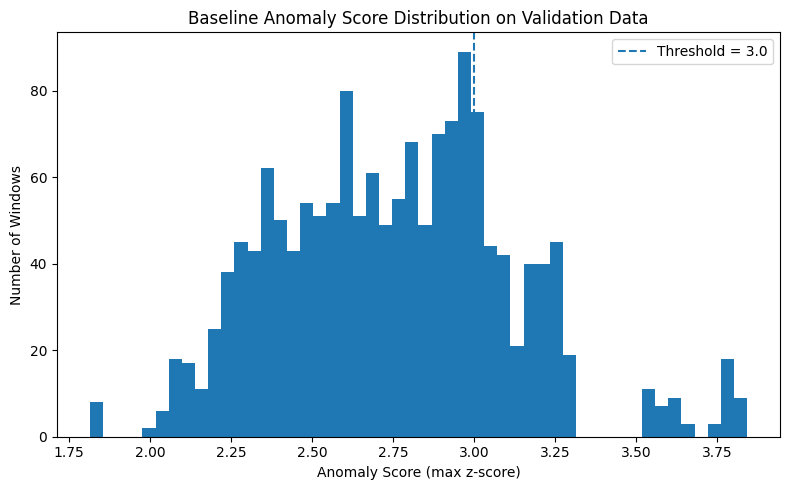

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(anomaly_score, bins=50)
plt.axvline(threshold, linestyle='--', label=f'Threshold = {threshold}')
plt.xlabel("Anomaly Score (max z-score)")
plt.ylabel("Number of Windows")
plt.title("Baseline Anomaly Score Distribution on Validation Data")
plt.legend()
plt.tight_layout()
plt.savefig("project/figures/baseline_anomaly_score_hist.png", dpi=300)
plt.show()

In [27]:
100 * anomaly_flags.mean()

np.float64(23.170731707317074)